In [1]:
# === SEL 1: Setup & Install ===
!pip install scikit-posthocs --quiet

import pandas as pd
import numpy as np
import math
from collections import Counter
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt

AGENTS = ["FSM", "Utility", "MAB"]
TACTICAL = ["light_attack", "heavy_attack", "block", "dodge", "use_skill"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00


In [2]:
# === SEL 2: Fungsi Perhitungan Metrik ===
def action_entropy(actions):
    """Action Entropy (Shannon) — mengukur VARIABILITAS aksi.
    Tinggi = aksi beragam & merata. Rendah = terpaku sedikit aksi."""
    n = len(actions)
    if n == 0: return 0.0
    c = Counter(actions)
    return -sum((k/n) * math.log2(k/n) for k in c.values())

def transition_entropy(actions):
    """Transition Entropy Global — mengukur STABILITAS/keteraturan urutan.
    Berbasis distribusi pasangan transisi (A->B). Bentuk dari entropy rate.
    Rendah = perpindahan teratur/prediktabel. Tinggi = tak menentu."""
    if len(actions) < 2: return 0.0
    trans = [(actions[i], actions[i+1]) for i in range(len(actions)-1)]
    n = len(trans); c = Counter(trans)
    return -sum((k/n) * math.log2(k/n) for k in c.values())

def acad(timestamps, actions):
    """ACAD (Average Consecutive Action Duration) — metrik pelengkap eksploratori.
    Rata-rata durasi segmen aksi yang sama berturut. Keterbatasan: pada sistem
    ini tiap aksi otomatis berganti setelah animasi, sehingga interpretasinya
    lebih dekat ke interval antar-keputusan."""
    if len(actions) < 2: return 0.0
    segs = []; i = 0
    while i < len(actions):
        j = i
        while j+1 < len(actions) and actions[j+1] == actions[i]: j += 1
        start = timestamps[i]
        end = timestamps[j+1] if j+1 < len(timestamps) else timestamps[j]
        segs.append((end - start) / 1000.0); i = j+1
    return np.mean(segs) if segs else 0.0

In [3]:
# === SEL 3: Muat Data & Hitung Metrik per Sesi ===
def per_session_metrics(agent):
    raw = pd.read_csv(f"raw_{agent}.csv")
    summ = pd.read_csv(f"summary_{agent}.csv")
    rows = []
    for s in sorted(raw['session'].unique()):
        sub = raw[raw['session'] == s].sort_values('timestamp_ms')
        acts = sub['action'].tolist()
        ts = sub['timestamp_ms'].tolist()
        srow = summ[summ['session'] == s].iloc[0]
        rows.append({
            'agent': agent, 'session': int(s),
            'entropy': action_entropy(acts),
            'trans_entropy': transition_entropy(acts),
            'acad': acad(ts, acts),
            'latency': sub['latency_us'].mean(),
            'survival': srow['survival_sec'],
            'memory': srow.get('mem_mb', np.nan),
        })
    return pd.DataFrame(rows)

data = pd.concat([per_session_metrics(a) for a in AGENTS], ignore_index=True)
data.to_csv("metrics_per_session.csv", index=False)  # simpan hasil
print("Data per sesi tersimpan. Contoh:")
print(data.head())

Data per sesi tersimpan. Contoh:
  agent  session   entropy  trans_entropy      acad    latency  survival  \
0   FSM        1  2.189011       3.016876  1.987579  17.789474    40.022   
1   FSM        2  2.189011       3.016876  1.988632  17.789474    40.052   
2   FSM        3  2.189011       3.016876  1.987684  18.263158    40.051   
3   FSM        4  2.189011       3.016876  1.987632  17.894737    40.085   
4   FSM        5  2.189011       3.016876  1.987789  17.894737    40.026   

   memory  
0  69.874  
1  69.904  
2  69.904  
3  69.904  
4  69.904  


In [4]:
# === SEL 4: Statistik Deskriptif (untuk tabel Bab 4) ===
metrics = ['entropy', 'trans_entropy', 'acad', 'latency', 'survival', 'memory']
labels = {'entropy':'Action Entropy', 'trans_entropy':'Transition Entropy',
          'acad':'ACAD (s)', 'latency':'Latency (us)', 'survival':'Survival (s)',
          'memory':'Memori (MB)'}

desc = data.groupby('agent')[metrics].agg(['mean', 'std'])
print("=== STATISTIK DESKRIPTIF ===")
print(desc.round(4).to_string())
desc.round(4).to_csv("deskriptif.csv")

=== STATISTIK DESKRIPTIF ===
        entropy         trans_entropy            acad          latency         survival           memory        
           mean     std          mean     std    mean     std     mean     std     mean     std     mean     std
agent                                                                                                           
FSM      2.1890  0.0000        3.0169  0.0000  1.9877  0.0002  19.0175  1.7591  40.0546  0.0257  69.9030  0.0055
MAB      0.7178  0.2937        1.0853  0.5413  8.7789  3.9506  34.1888  3.3310  31.8252  1.1046  69.9151  0.0003
Utility  2.2608  0.0000        3.1019  0.0000  2.0901  0.0022  44.1556  7.7480  39.9291  0.0393  69.9168  0.0009


In [5]:
# === SEL 5: Uji Asumsi (Shapiro-Wilk & Levene) ===
print("=== UJI ASUMSI (menentukan parametrik vs non-parametrik) ===\n")
for m in ['entropy','trans_entropy','acad','latency','survival']:
    print(f"--- {labels[m]} ---")
    groups = [data[data['agent']==a][m].values for a in AGENTS]
    for a, g in zip(AGENTS, groups):
        if np.std(g) == 0:
            print(f"  Shapiro {a}: varians=0 (deterministik/konstan -> tidak normal)")
        else:
            w, p = stats.shapiro(g)
            note = "normal" if p > 0.05 else "TIDAK normal"
            print(f"  Shapiro {a}: W={w:.3f}, p={p:.4g} ({note})")
    lw, lp = stats.levene(*groups)
    print(f"  Levene: W={lw:.3f}, p={lp:.4g} ({'homogen' if lp>0.05 else 'TIDAK homogen'})")
    print(f"  -> Kesimpulan: ANOVA {'terpenuhi' if False else 'DILANGGAR'} -> pakai Kruskal-Wallis\n")

=== UJI ASUMSI (menentukan parametrik vs non-parametrik) ===

--- Action Entropy ---
  Shapiro FSM: W=1.000, p=1 (normal)
  Shapiro Utility: W=1.000, p=1 (normal)
  Shapiro MAB: W=0.895, p=0.006208 (TIDAK normal)
  Levene: W=37.108, p=2.223e-12 (TIDAK homogen)
  -> Kesimpulan: ANOVA DILANGGAR -> pakai Kruskal-Wallis

--- Transition Entropy ---
  Shapiro FSM: W=1.000, p=1 (normal)
  Shapiro Utility: W=1.000, p=1 (normal)
  Shapiro MAB: W=0.892, p=0.005384 (TIDAK normal)
  Levene: W=37.913, p=1.442e-12 (TIDAK homogen)
  -> Kesimpulan: ANOVA DILANGGAR -> pakai Kruskal-Wallis

--- ACAD (s) ---
  Shapiro FSM: W=0.538, p=1.368e-08 (TIDAK normal)
  Shapiro Utility: W=0.226, p=1.766e-11 (TIDAK normal)
  Shapiro MAB: W=0.807, p=8.745e-05 (TIDAK normal)
  Levene: W=25.210, p=2.312e-09 (TIDAK homogen)
  -> Kesimpulan: ANOVA DILANGGAR -> pakai Kruskal-Wallis

--- Latency (us) ---
  Shapiro FSM: W=0.851, p=0.0006543 (TIDAK normal)
  Shapiro Utility: W=0.634, p=1.956e-07 (TIDAK normal)
  Shapiro MAB

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
# === SEL 6: Kruskal-Wallis + Dunn (Bonferroni) ===
print("=== UJI HIPOTESIS: KRUSKAL-WALLIS + DUNN (BONFERRONI) ===\n")
for m in ['entropy','trans_entropy','acad','latency','survival']:
    print(f"--- {labels[m]} ---")
    groups = [data[data['agent']==a][m].values for a in AGENTS]
    h, hp = stats.kruskal(*groups)
    sig = "SIGNIFIKAN (H0 ditolak)" if hp < 0.05 else "tidak signifikan"
    print(f"  Kruskal-Wallis: H={h:.3f}, p={hp:.4g} -> {sig}")
    if hp < 0.05:
        dunn = sp.posthoc_dunn(data, val_col=m, group_col='agent', p_adjust='bonferroni')
        print("  Dunn post-hoc (p-value Bonferroni):")
        print("   ", dunn.round(6).to_string().replace('\n', '\n    '))
    print()

=== UJI HIPOTESIS: KRUSKAL-WALLIS + DUNN (BONFERRONI) ===

--- Action Entropy ---
  Kruskal-Wallis: H=85.559, p=2.636e-19 -> SIGNIFIKAN (H0 ditolak)
  Dunn post-hoc (p-value Bonferroni):
                  FSM       MAB   Utility
    FSM      1.000000  0.000011  0.000011
    MAB      0.000011  1.000000  0.000000
    Utility  0.000011  0.000000  1.000000

--- Transition Entropy ---
  Kruskal-Wallis: H=85.559, p=2.637e-19 -> SIGNIFIKAN (H0 ditolak)
  Dunn post-hoc (p-value Bonferroni):
                  FSM       MAB   Utility
    FSM      1.000000  0.000011  0.000011
    MAB      0.000011  1.000000  0.000000
    Utility  0.000011  0.000000  1.000000

--- ACAD (s) ---
  Kruskal-Wallis: H=79.266, p=6.133e-18 -> SIGNIFIKAN (H0 ditolak)
  Dunn post-hoc (p-value Bonferroni):
                  FSM       MAB   Utility
    FSM      1.000000  0.000000  0.000026
    MAB      0.000000  1.000000  0.000026
    Utility  0.000026  0.000026  1.000000

--- Latency (us) ---
  Kruskal-Wallis: H=75.451, p=4

/tmp/ipykernel_2641/759457767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=AGENTS)
/tmp/ipykernel_2641/759457767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=AGENTS)
/tmp/ipykernel_2641/759457767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=AGENTS)
/tmp/ipykernel_2641/759457767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=AGENTS)
/tmp/ipykernel_2641/7594

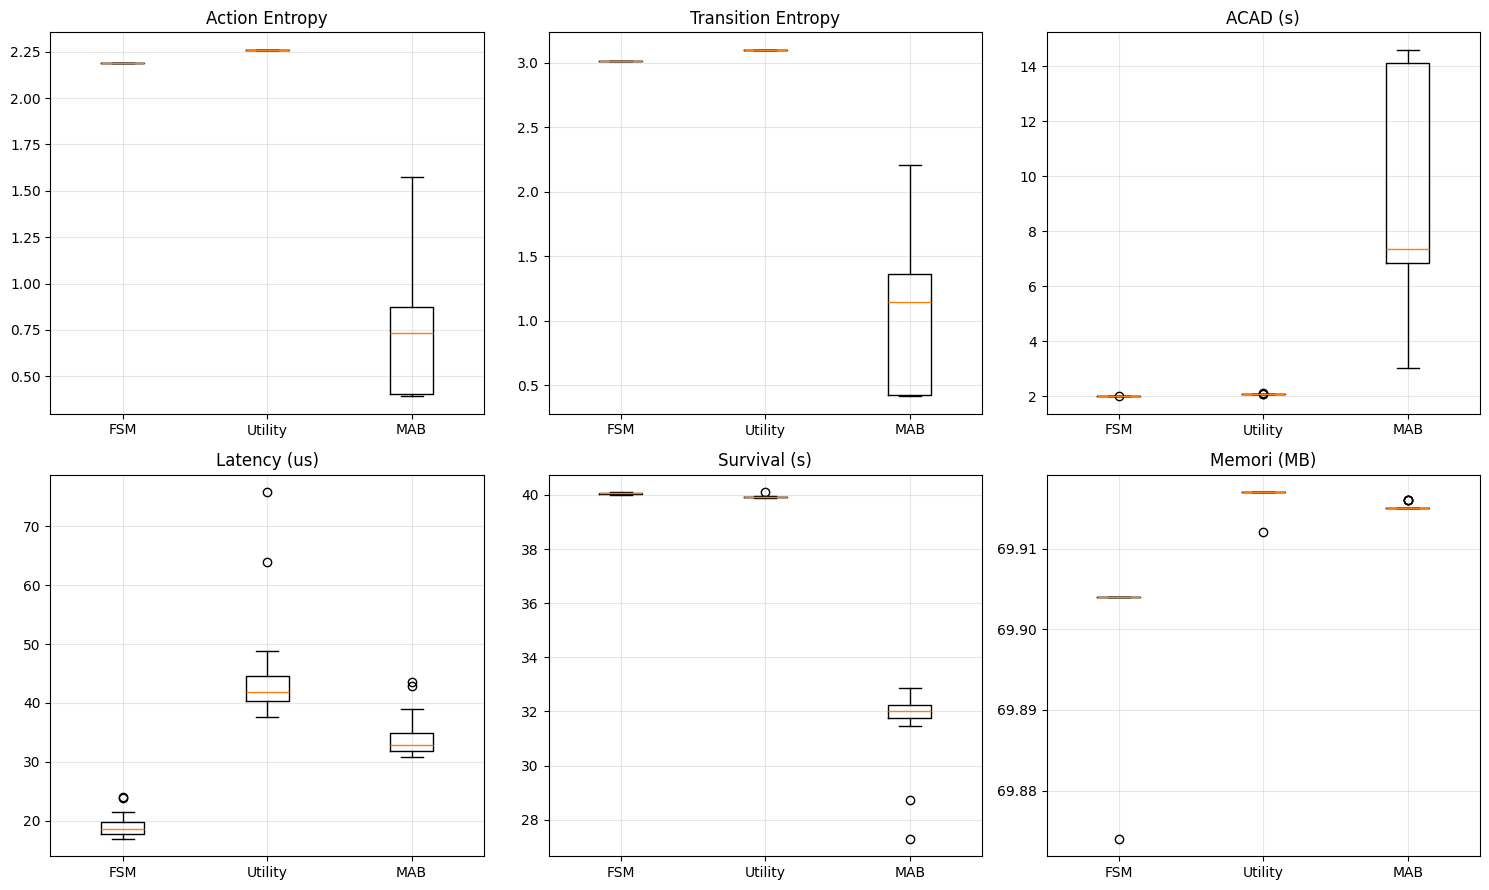

Boxplot tersimpan sebagai boxplots.png


In [9]:
# === SEL 7: Visualisasi Boxplot (untuk lampiran Bab 4) ===
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m in zip(axes.flat, metrics):
    plot_data = [data[data['agent']==a][m].dropna().values for a in AGENTS]
    ax.boxplot(plot_data, labels=AGENTS)
    ax.set_title(labels[m])
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Boxplot tersimpan sebagai boxplots.png")

In [8]:
# === SEL 8: Distribusi Aksi per Agen (untuk pembahasan) ===
print("=== DISTRIBUSI AKSI (agregat 30 sesi) ===\n")
for a in AGENTS:
    raw = pd.read_csv(f"raw_{a}.csv")
    c = Counter(raw['action'])
    total = sum(c.values())
    print(f"{a}:")
    for act in TACTICAL:
        n = c.get(act, 0)
        print(f"  {act:14s}: {n:4d} ({100*n/total:.1f}%)")
    print()

=== DISTRIBUSI AKSI (agregat 30 sesi) ===

FSM:
  light_attack  :  180 (31.6%)
  heavy_attack  :  150 (26.3%)
  block         :  120 (21.1%)
  dodge         :   60 (10.5%)
  use_skill     :   60 (10.5%)

Utility:
  light_attack  :  120 (22.2%)
  heavy_attack  :   90 (16.7%)
  block         :  150 (27.8%)
  dodge         :   60 (11.1%)
  use_skill     :  120 (22.2%)

MAB:
  light_attack  :   42 (10.4%)
  heavy_attack  :  324 (80.4%)
  block         :   11 (2.7%)
  dodge         :    8 (2.0%)
  use_skill     :   18 (4.5%)

